# Домашнее задание по теме "Коллаборативная фильтрация"

## Этап 1. Загрузка и подготовка данных

In [2]:
from surprise import KNNBasic, Dataset, Reader
from surprise.model_selection import cross_validate

# 1. Загрузка данных 100K (оптимально для RAM)
data = Dataset.load_builtin('ml-100k')

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /Users/acer/.surprise_data/ml-100k


## Этап 2. Исследовательский анализ данных (EDA)

In [11]:
#Диапазон оценок в датасете
print(data.reader.rating_scale)

(1, 5)


In [13]:
# Посмотреть как хранятся данные
for rating in data.raw_ratings[:1]:
    print(rating)

('196', '242', 3.0, '881250949')


### Анализ распределения оценок

Для реализации исследовательского анализа данных нам необходимо перевести данные в DataFrame

In [14]:
import pandas as pd

# Извлекаем сырые данные (user, item, rating, timestamp)
raw_data = data.raw_ratings

# Создаем стандартный Pandas DataFrame
df = pd.DataFrame(raw_data, columns=['user_id', 'item_id', 'rating', 'timestamp'])
print(df.head())

  user_id item_id  rating  timestamp
0     196     242     3.0  881250949
1     186     302     3.0  891717742
2      22     377     1.0  878887116
3     244      51     2.0  880606923
4     166     346     1.0  886397596


### Анализ разреженности матрицы оценок

Оценка ставится не для каждой пары «пользователь — фильм». Посчитаем долю реальных оценок среди всех теоретически возможных пар.

In [63]:
# Считаем уникальные пары, чтобы повторная оценка одной пары не завышала плотность
n_users = df['user_id'].nunique()
n_movies = df['item_id'].nunique()
n_real_pairs = df[['user_id', 'item_id']].drop_duplicates().shape[0]
n_possible_pairs = n_users * n_movies
density = n_real_pairs / n_possible_pairs
sparsity = 1 - density

sparsity_table = pd.DataFrame({
    'Показатель': [
        'Пользователи', 'Фильмы', 'Реальные оценки',
        'Все возможные пары', 'Доля реальных оценок', 'Разреженность'
    ],
    'Значение': [
        n_users, n_movies, n_real_pairs, n_possible_pairs,
        f'{density:.2%}', f'{sparsity:.2%}'
    ]
})

display(sparsity_table)

,Показатель,Значение
0,Пользователи,943
1,Фильмы,1682
2,Реальные оценки,100000
3,Все возможные пары,1586126
4,Доля реальных оценок,6.30%
5,Разреженность,93.70%


В MovieLens 100K заполнено только 6,30% матрицы оценок, то есть 93,70% пар не имеют оценки. Такая высокая разреженность важна для коллаборативной фильтрации: у пользователей и фильмов меньше общих оценок, по которым можно надёжно вычислить сходство.

Строим распределение оценок

/var/folders/6w/fwb_07rx7c3_dpz1j_x3zv880000gn/T/ipykernel_5556/462855834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


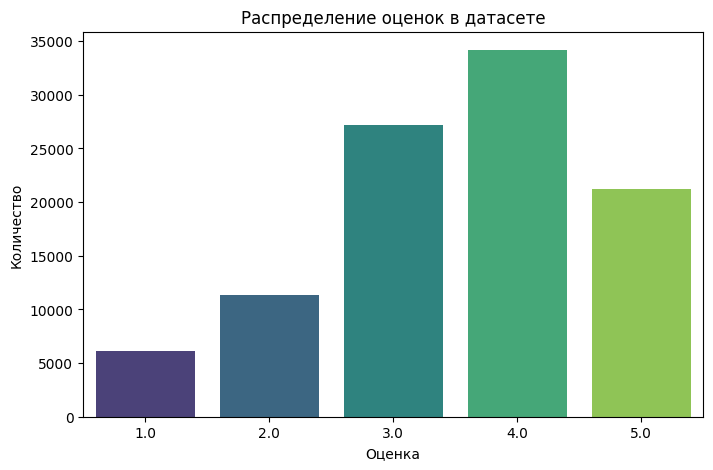

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Распределение оценок в датасете')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.show()

Как видно из визуализации, чаще всего пользователи ставят оценку "4" и "3", реже "5" и в довольно редких случаях "1" и "2".


### Активность пользователей

Рассмотрим распределение количества оценок на одного пользователя.

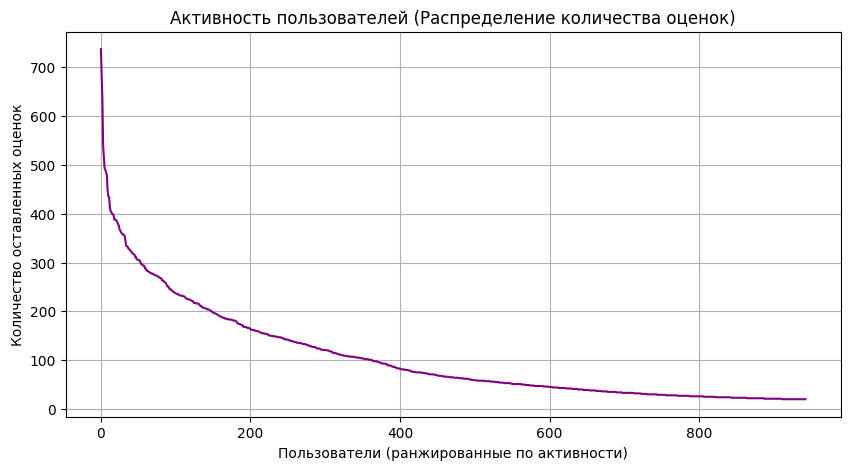

In [16]:
user_counts = df['user_id'].value_counts()

plt.figure(figsize=(10, 5))
plt.plot(user_counts.values, color='purple')
plt.title('Активность пользователей (Распределение количества оценок)')
plt.xlabel('Пользователи (ранжированные по активности)')
plt.ylabel('Количество оставленных оценок')
plt.grid(True)
plt.show()

Как видно из визуализации - большое количество пользователей довольно редко ставят оценки, и лишь небольшая доля участников является действительно активными пользователями, ставящими оценки на большинство фильмов.

### Популярность фильмов

In [54]:
movie_stats = df.groupby('item_id').agg(
    просмотры=('rating', 'count'),
    средний_рейтинг=('rating', 'mean')
).reset_index()

# 3. Сортируем по количеству просмотров и берем топ-10
top_popular = movie_stats.sort_values(by='просмотры', ascending=False).head(10)

# Округлим средний рейтинг для красоты
top_popular['средний_рейтинг'] = top_popular['средний_рейтинг'].round(2)

print("Топ-10 самых популярных фильмов (по количеству оценок):")
print(top_popular.to_string(index=False))

Топ-10 самых популярных фильмов (по количеству оценок):
item_id  просмотры  средний_рейтинг
     50        583             4.36
    258        509             3.80
    100        508             4.16
    181        507             4.01
    294        485             3.16
    286        481             3.66
    288        478             3.44
      1        452             3.88
    300        431             3.63
    121        429             3.44


## Этап 3. Реализация моделей

### User-based

In [55]:
from surprise import KNNWithMeans, KNNBasic
from surprise import accuracy
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=1)

# Настройка User-based фильтрации
algo = KNNWithMeans(k=50, sim_options={
    'name': 'cosine',
    'user_based': True  # compute  similarities between users
})

model_user = algo.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


### Item-based

In [56]:
# Настройка Item-based фильтрации
algo_item = KNNWithMeans(k=50, sim_options={
    'name': 'cosine',
    'user_based': False  # compute  similarities between users
})

model_item = algo_item.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Этап 4. Кросс-валидация и оценка качества

In [64]:
from surprise.model_selection import KFold

cv_results = {}
for model_name, user_based in {
    'User-based CF': True,
    'Item-based CF': False
}.items():
    model = KNNWithMeans(
        k=50,
        sim_options={'name': 'cosine', 'user_based': user_based}
    )
    cv_results[model_name] = cross_validate(
        model,
        data,
        measures=['RMSE', 'MAE'],
        cv=KFold(n_splits=5, random_state=42, shuffle=True),
        verbose=False
    )

metrics_table = pd.DataFrame({
    'Модель': cv_results.keys(),
    'Средний RMSE': [result['test_rmse'].mean() for result in cv_results.values()],
    'Средний MAE': [result['test_mae'].mean() for result in cv_results.values()]
}).round(4)

print('Итоговое сравнение моделей по 5-fold кросс-валидации:')
display(metrics_table)

Итоговое сравнение моделей по 5-fold кросс-валидации:


,Модель,Средний RMSE,Средний MAE
0,User-based CF,0.9539,0.7530
1,Item-based CF,0.9406,0.7394


Item-based модель показала немного лучшие результаты. Выберем item-based модель, создадим её заново и обучим на всём наборе оценок, а затем будем использовать для выдачи рекомендаций. Так модель увидит максимум доступной информации.

In [58]:
best_model = KNNWithMeans(
    k=50,
    sim_options={'name': 'cosine', 'user_based': False}
)

full_trainset = data.build_full_trainset()
best_model.fit(full_trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Этап 5. Проверка «в полях» и выводы

In [60]:
def get_top_n(user_id, model, dataset, n=5):
    user_id = str(user_id)

    all_items = dataset['item_id'].astype(str).unique()
    seen_items = set(
        dataset.loc[
            dataset['user_id'].astype(str) == user_id,
            'item_id'
        ].astype(str)
    )

    predictions = [
        (item_id, model.predict(user_id, item_id).est)
        for item_id in all_items
        if item_id not in seen_items
    ]

    return sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

In [62]:
get_top_n('2', best_model, df)

[('1189', 5), ('1500', 5), ('814', 5), ('1536', 5), ('1293', 5)]

## Вывод

Для построения рекомендательной системы был использован датасет MovieLens 100K, содержащий 100 000 оценок 943 пользователей для 1 682 фильмов. Наиболее частыми являются оценки 4 и 3, что говорит о преобладании положительных и нейтрально-положительных оценок. Матрица оценок содержит 1 586 126 теоретически возможных пар «пользователь — фильм», из которых реальными оценками заполнены только 100 000: плотность равна 6,30%, а разреженность — 93,70%.
В ходе работы были реализованы два подхода коллаборативной фильтрации на основе алгоритма KNNWithMeans: user-based и item-based. Для объективной и воспроизводимой оценки моделей проведена кросс-валидация на 5 одинаковых фолдах с фиксированным random_state = 42; использованы метрики RMSE и MAE.
User-based модель показала средние значения RMSE = 0,9539 и MAE = 0,7530. Для item-based модели значения составили RMSE = 0,9406 и MAE = 0,7394. Поскольку для обеих метрик меньшее значение означает более точный прогноз, item-based подход оказался лучше: RMSE уменьшилась примерно на 1,4%, а MAE — на 1,8%.
Следовательно, в рамках выбранной конфигурации наиболее точной моделью является item-based коллаборативная фильтрация. Это означает, что для MovieLens 100K сходство между фильмами позволяет точнее предсказывать пользовательские оценки, чем сходство между пользователями. При этом разница между моделями небольшая, поэтому для окончательного выбора стоит дополнительно проверить качество ранжирования рекомендаций и подобрать гиперпараметры.